# ALY 6130 Signature Assessment
## Apple Inc. Proposed Acquisition of Netflix
### Notebook 4 of 4 — Monte Carlo Simulation

50,000 trials per risk, fixed seed. Each simulation produces a loss distribution, from which we read expected loss, standard deviation, and the 95th percentile tail.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
rng = np.random.default_rng(42)
NSIM = 50000

## R1 — Regulatory and antitrust

In [2]:
u=rng.random(NSIM); loss=np.empty(NSIM)
clean=u<0.30; remedy=(u>=0.30)&(u<0.75); block=u>=0.75
loss[clean]=rng.triangular(0,0.2,0.6,clean.sum())
loss[remedy]=rng.triangular(3,8,18,remedy.sum())
loss[block]=rng.triangular(15,30,55,block.sum())
print(f'E[loss]=${loss.mean():.2f}B  SD=${loss.std():.2f}B  P95=${np.percentile(loss,95):.2f}B')

E[loss]=$12.80B  SD=$13.38B  P95=$40.92B


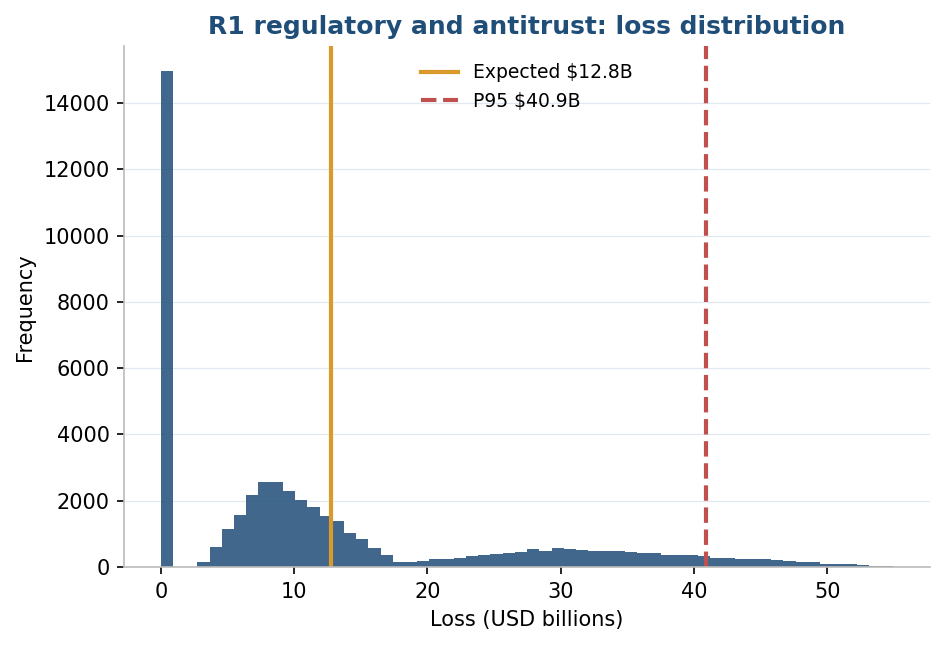

In [3]:
Image('../figures/r1_regulatory_loss_mc.png')

## R2 — Churn revenue at risk
Base 300M subscribers, ARPU $12, baseline monthly churn 2.5 percent. Each lost subscriber forgoes about six months of first year revenue.

In [4]:
subs=300e6; arpu=12.0; baseline=0.025
mc=np.clip(rng.normal(0.032,0.006,NSIM),baseline,0.08)
subs_lost=subs*(mc-baseline)*12
rev=subs_lost*arpu*6/1e9
print(f'E[rev loss]=${rev.mean():.2f}B  P95=${np.percentile(rev,95):.2f}B  subs lost~{subs_lost.mean()/1e6:.1f}M')

E[rev loss]=$1.91B  P95=$4.37B  subs lost~26.6M


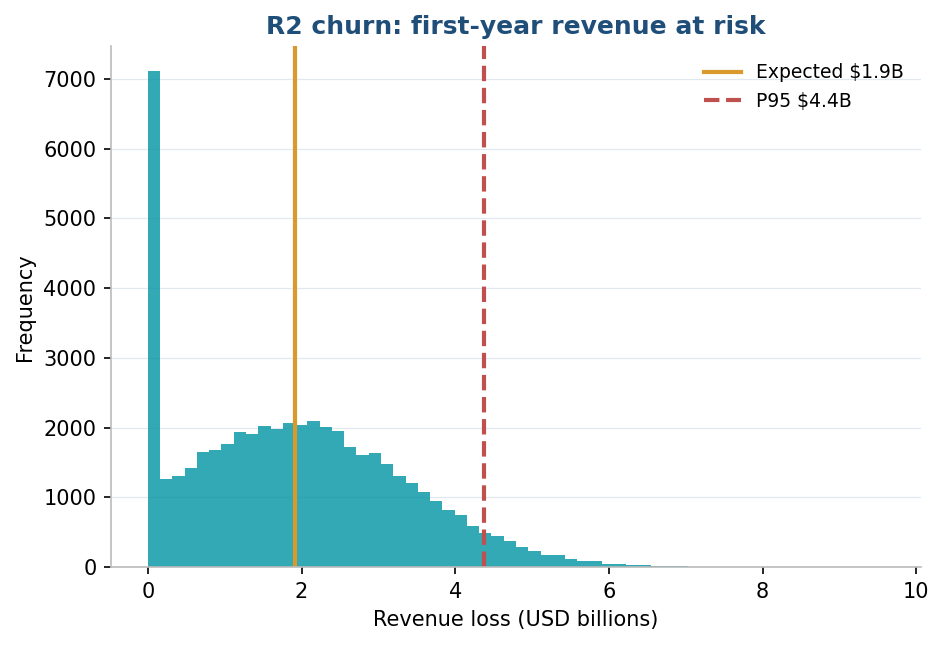

In [5]:
Image('../figures/r2_revenue_loss_mc.png')

## R3 — Cyber annualized loss exposure (FAIR)

In [6]:
lam=0.8; ale=np.zeros(NSIM); n_events=rng.poisson(lam,NSIM); tot=int(n_events.sum())
records=rng.lognormal(np.log(1_000_000),0.85,tot)
cost=rng.triangular(120,165,210,tot)
resp=rng.lognormal(np.log(15e6),0.6,tot)
ev=records*cost+resp; idx=0
for i,k in enumerate(n_events):
    if k>0: ale[i]=ev[idx:idx+k].sum(); idx+=k
ale_B=ale/1e9
print(f'E[ALE]=${ale_B.mean():.3f}B  P95=${np.percentile(ale_B,95):.3f}B  P99=${np.percentile(ale_B,99):.3f}B')

E[ALE]=$0.203B  P95=$0.811B  P99=$1.406B


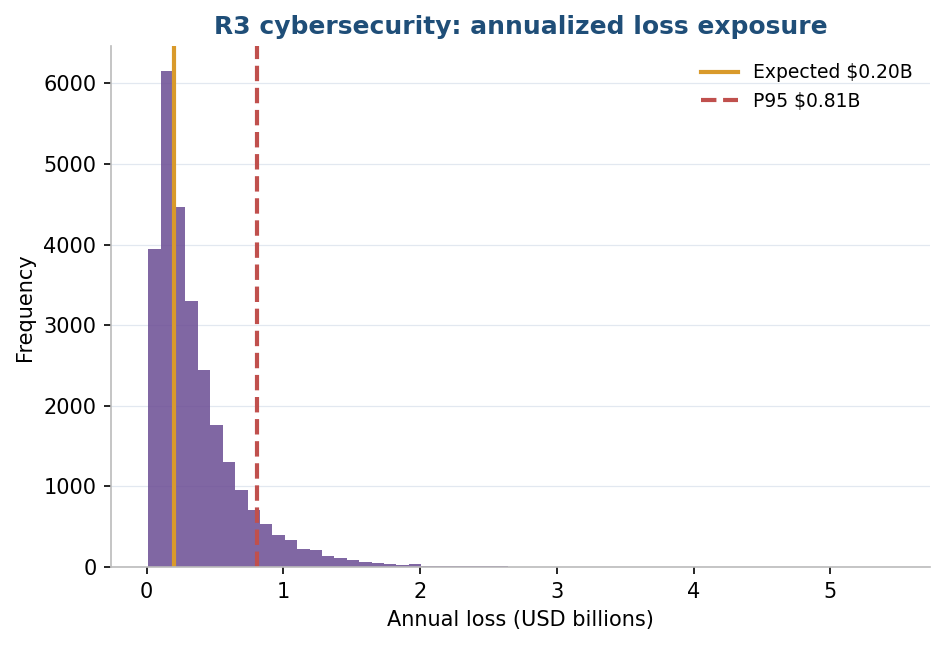

In [7]:
Image('../figures/r3_cyber_ale_mc.png')

## Risk exposure summary
R1 dominates the exposure, R2 is material, and R3 is smaller but with a heavy tail. This ranking drives the response strategy and the order of management attention.

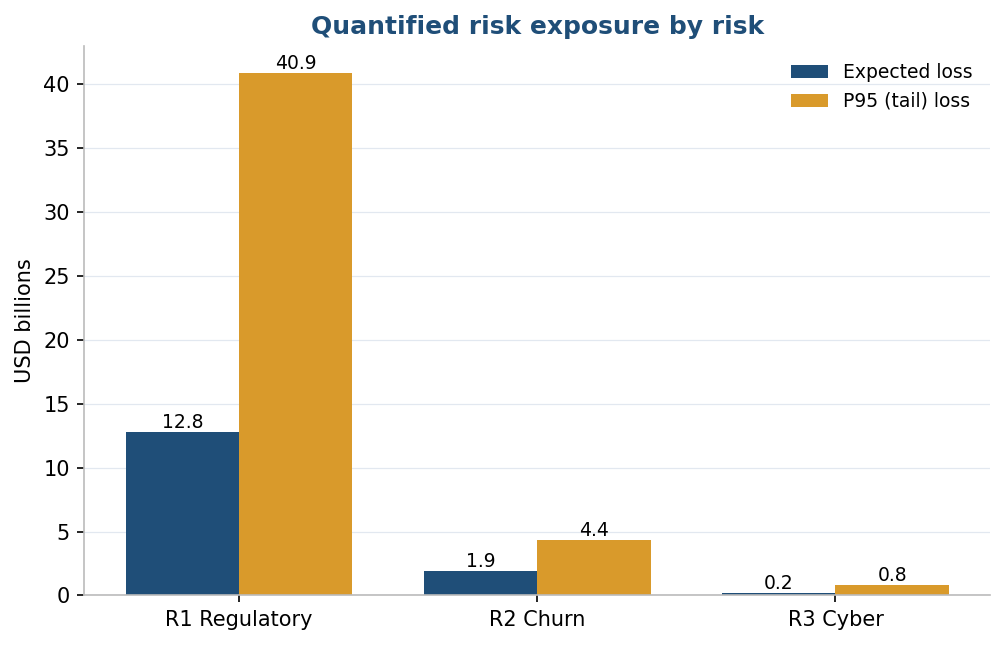

In [8]:
Image('../figures/risk_exposure_summary.png')

**Conclusion of the quantitative work.** Expected losses are about $12.8B for R1, $1.9B for R2, and $0.20B for R3, with P95 tails of $40.9B, $4.4B, and $0.81B. The numbers confirm the qualitative ranking and set the priorities in the response strategy.